# Phase 1: Data Exploration
**Exercise 3 — Wearable Activity Monitoring**

Sections:
1. Setup & dataset survey (label distributions, sensor availability)
2. Raw signal visualisation (single recording)
3. Accelerometer magnitude — the core signal
4. Watch location comparison
5. Activity comparison
6. Path-distinguishing features
7. Step count ground truth overview
8. Windowed feature preview

## 1. Setup

In [15]:
import os
import pickle
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import signal as scipy_signal

from mhealth_activity import Recording, Trace, Activity, WatchLocation, Path

TRAIN_DIR = 'data/train'
TEST_DIR  = 'data/test'
MAP_PATH  = 'documents/mapzurich.png'

WATCH_LOC_NAMES  = {0: 'Wrist', 1: 'Belt', 2: 'Ankle'}
WATCH_LOC_COLORS = {0: '#2196F3', 1: '#FF9800', 2: '#4CAF50'}
PATH_NAMES       = {0: 'Path 0 (Central→Main)', 1: 'Path 1 (Central→Main Clausius)',
                    2: 'Path 2 (Walche→Main)', 3: 'Path 3 (Main→Walche)', 4: 'Path 4 (Main→Bahnhof)'}
PATH_COLORS      = {0: '#E91E63', 1: '#9C27B0', 2: '#00BCD4', 3: '#009688', 4: '#FF5722'}
ACT_COLORS       = {'standing': '#607D8B', 'walking': '#4CAF50', 'running': '#FF9800', 'cycling': '#2196F3'}

train_files = sorted([os.path.join(TRAIN_DIR, f) for f in os.listdir(TRAIN_DIR)])
test_files  = sorted([os.path.join(TEST_DIR,  f) for f in os.listdir(TEST_DIR)])
print(f'Training recordings : {len(train_files)}')
print(f'Test recordings     : {len(test_files)}')

Training recordings : 396
Test recordings     : 280


## 2. Dataset Survey — Label Distributions

In [16]:

# Load all training labels quickly (no full Recording parse needed)
all_labels = []
all_keys   = []
for fpath in train_files:
    with open(fpath, 'rb') as f:
        d = pickle.load(f)
    all_labels.append(d['labels'])
    all_keys.append(set(d['data'].keys()))

ACT_INT_MAP = {0: 'standing', 1: 'walking', 2: 'running', 3: 'cycling'}

def normalize_acts(raw):
    """Activities are either a dict {'walking': True, ...} or a list of ints [0, 1, 2, 3]."""
    if isinstance(raw, dict):
        return raw
    if isinstance(raw, list):
        return {name: (i in raw) for i, name in ACT_INT_MAP.items()}
    return {name: False for name in ACT_INT_MAP.values()}

def has_valid_step(s):
    """step_count is None, -1 (both = unlabeled) or a numpy/Python int (actual count)."""
    return s is not None and s != -1

watch_locs  = [l['watch_loc']  for l in all_labels]
path_idxs   = [l['path_idx']   for l in all_labels]
step_counts = [l.get('step_count', None) for l in all_labels]
acts        = [normalize_acts(l.get('activities', {})) for l in all_labels]

print('=== Watch Location ===')
for k, v in sorted(Counter(watch_locs).items()):
    print(f'  {WATCH_LOC_NAMES[k]:8s}: {v}')

print('\n=== Path Index ===')
for k, v in sorted(Counter(path_idxs).items()):
    print(f'  Path {k}: {v}')

valid_steps = [int(s) for s in step_counts if has_valid_step(s)]
print(f'\n=== Step Count ===')
print(f'  Available : {len(valid_steps)} / {len(step_counts)}')
print(f'  Min / Max : {min(valid_steps)} / {max(valid_steps)}')
print(f'  Mean      : {np.mean(valid_steps):.0f}  Median: {np.median(valid_steps):.0f}')

print('\n=== Activities (training labels — weak!) ===')
for act in ['standing', 'walking', 'running', 'cycling']:
    n = sum(1 for a in acts if a.get(act, False))
    print(f'  {act:10s}: {n} / {len(acts)}')


=== Watch Location ===
  Wrist   : 134
  Belt    : 123
  Ankle   : 139

=== Path Index ===
  Path 0: 82
  Path 1: 76
  Path 2: 74
  Path 3: 71
  Path 4: 93

=== Step Count ===
  Available : 33 / 396
  Min / Max : 0 / 1077
  Mean      : 444  Median: 287

=== Activities (training labels — weak!) ===
  standing  : 95 / 396
  walking   : 366 / 396
  running   : 76 / 396
  cycling   : 56 / 396


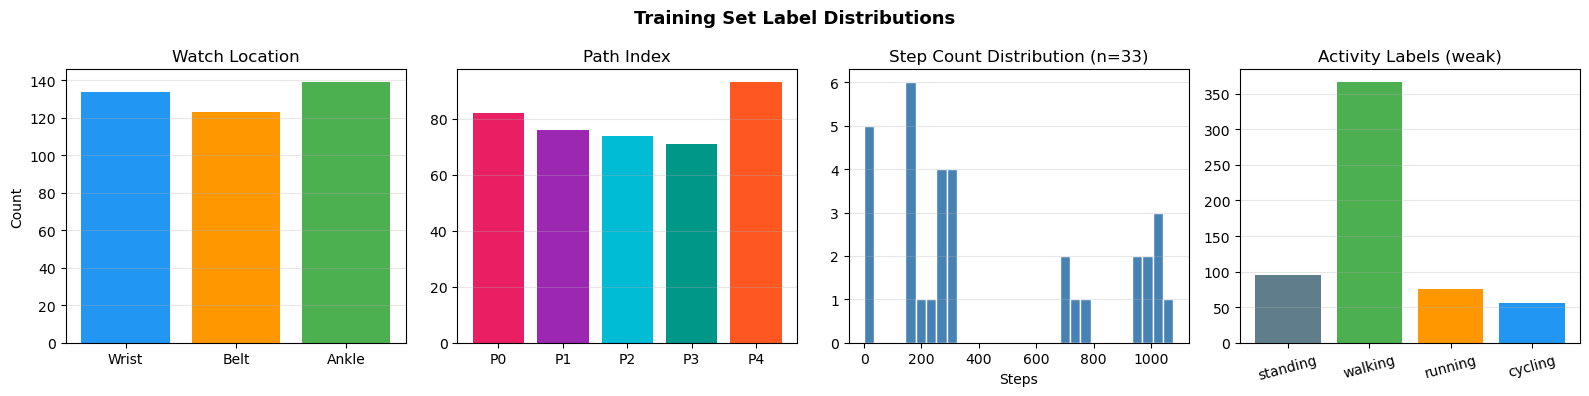

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Watch location
wl_counts = [Counter(watch_locs)[k] for k in range(3)]
axes[0].bar([WATCH_LOC_NAMES[k] for k in range(3)], wl_counts,
            color=[WATCH_LOC_COLORS[k] for k in range(3)])
axes[0].set_title('Watch Location')
axes[0].set_ylabel('Count')

# Path
p_counts = [Counter(path_idxs)[k] for k in range(5)]
axes[1].bar([f'P{k}' for k in range(5)], p_counts,
            color=[PATH_COLORS[k] for k in range(5)])
axes[1].set_title('Path Index')

# Step count distribution
axes[2].hist(valid_steps, bins=30, color='steelblue', edgecolor='white')
axes[2].set_title(f'Step Count Distribution (n={len(valid_steps)})')
axes[2].set_xlabel('Steps')

# Activities
act_names = ['standing', 'walking', 'running', 'cycling']
act_counts = [sum(1 for a in acts if a.get(act, False)) for act in act_names]
axes[3].bar(act_names, act_counts, color=[ACT_COLORS[a] for a in act_names])
axes[3].set_title('Activity Labels (weak)')
axes[3].tick_params(axis='x', rotation=15)

for ax in axes:
    ax.grid(axis='y', alpha=0.3)
plt.suptitle('Training Set Label Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Sensor Availability Audit
Phone sensors are optional — we must know what fraction of recordings contain each sensor.

In [18]:
from collections import defaultdict

sensor_presence = defaultdict(int)
for keys in all_keys:
    for k in keys:
        sensor_presence[k] += 1

n = len(train_files)
always_present = [k for k, v in sensor_presence.items() if v == n]
optional       = [(k, v) for k, v in sensor_presence.items() if v < n]
optional.sort(key=lambda x: -x[1])

print(f'=== Always present ({len(always_present)} sensors) ===')
print(sorted(always_present))

print(f'\n=== Optional sensors (present in X/{n} recordings) ===')
for k, v in optional:
    bar = '█' * int(v / n * 30)
    print(f'  {k:30s}: {v:3d}/{n}  {bar}')

=== Always present (32 sensors) ===
['altitude', 'ax', 'ay', 'az', 'gx', 'gy', 'gz', 'mx', 'my', 'mz', 'packetNumber', 'phone_ax', 'phone_ay', 'phone_az', 'phone_gravx', 'phone_gravy', 'phone_gravz', 'phone_gx', 'phone_gy', 'phone_gz', 'phone_lax', 'phone_lay', 'phone_laz', 'phone_mx', 'phone_my', 'phone_mz', 'phone_rotm', 'phone_rotx', 'phone_roty', 'phone_rotz', 'temperature', 'timestamp']

=== Optional sensors (present in X/396 recordings) ===
  phone_orientationz            : 395/396  █████████████████████████████
  phone_orientationx            : 395/396  █████████████████████████████
  phone_orientationy            : 395/396  █████████████████████████████
  phone_pressure                : 329/396  ████████████████████████
  lostPackets                   : 253/396  ███████████████████
  speed                         : 245/396  ██████████████████
  bearing                       : 245/396  ██████████████████
  longitude                     : 245/396  ██████████████████
  latitude   

## 4. Raw Signal Visualisation — Single Recording
Change `RECORDING_IDX` to explore different traces.

In [19]:
RECORDING_IDX = 0   # <-- change this to explore

rec = Recording(train_files[RECORDING_IDX])
lbl = all_labels[RECORDING_IDX]
lbl_acts = normalize_acts(lbl.get('activities', {}))

print(f'File      : {rec.filename}')
print(f'Duration  : {rec.data["ax"].total_time:.1f}s  ({rec.data["ax"].total_time/60:.1f} min)')
print(f'Watch loc : {WATCH_LOC_NAMES[lbl["watch_loc"]]}')
print(f'Path      : {lbl["path_idx"]}')
sc = lbl.get('step_count')
print(f'Steps     : {sc} ({"labeled" if has_valid_step(sc) else "unknown"})')
print(f'Activities: { {k: v for k, v in lbl_acts.items() if v} }')
print(f'Sensors   : {sorted(rec.data.keys())}')


File      : train_trace_000.pkl
Duration  : 576.0s  (9.6 min)
Watch loc : Wrist
Path      : 0
Steps     : -1 (unknown)
Activities: {'walking': True}
Sensors   : ['altitude', 'ax', 'ay', 'az', 'gx', 'gy', 'gz', 'mx', 'my', 'mz', 'packetNumber', 'phone_ax', 'phone_ay', 'phone_az', 'phone_gravx', 'phone_gravy', 'phone_gravz', 'phone_gx', 'phone_gy', 'phone_gz', 'phone_lax', 'phone_lay', 'phone_laz', 'phone_light', 'phone_mx', 'phone_my', 'phone_mz', 'phone_orientationx', 'phone_orientationy', 'phone_orientationz', 'phone_pressure', 'phone_rotm', 'phone_rotx', 'phone_roty', 'phone_rotz', 'temperature', 'timestamp']


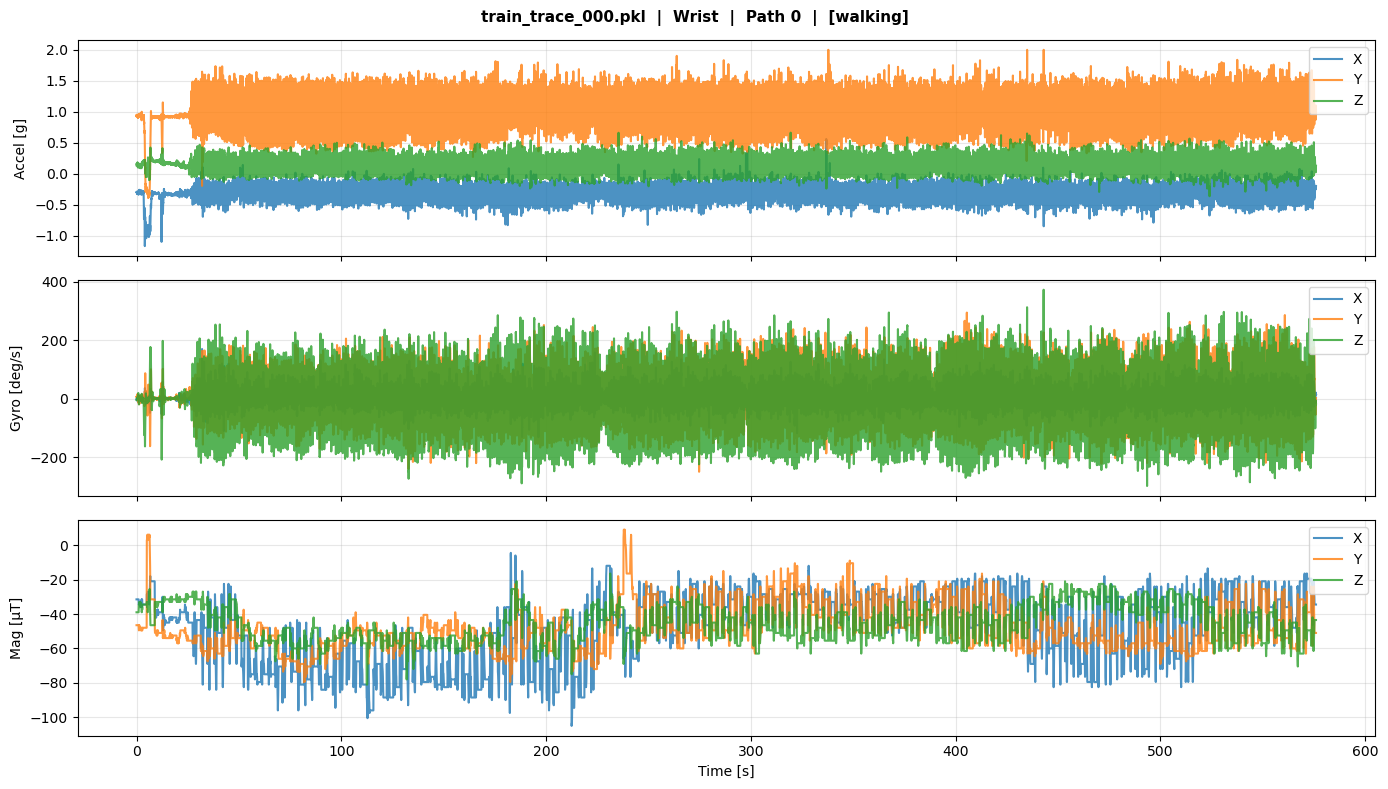

In [20]:
# Full recording: all smartwatch IMU channels
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

t_ax = rec.data['ax'].timestamps
axes[0].plot(t_ax, rec.data['ax'].values, label='X', alpha=0.8)
axes[0].plot(t_ax, rec.data['ay'].values, label='Y', alpha=0.8)
axes[0].plot(t_ax, rec.data['az'].values, label='Z', alpha=0.8)
axes[0].set_ylabel('Accel [g]')
axes[0].legend(loc='upper right')
axes[0].grid(alpha=0.3)

t_gx = rec.data['gx'].timestamps
axes[1].plot(t_gx, rec.data['gx'].values, label='X', alpha=0.8)
axes[1].plot(t_gx, rec.data['gy'].values, label='Y', alpha=0.8)
axes[1].plot(t_gx, rec.data['gz'].values, label='Z', alpha=0.8)
axes[1].set_ylabel('Gyro [deg/s]')
axes[1].legend(loc='upper right')
axes[1].grid(alpha=0.3)

t_mx = rec.data['mx'].timestamps
axes[2].plot(t_mx, rec.data['mx'].values, label='X', alpha=0.8)
axes[2].plot(t_mx, rec.data['my'].values, label='Y', alpha=0.8)
axes[2].plot(t_mx, rec.data['mz'].values, label='Z', alpha=0.8)
axes[2].set_ylabel('Mag [µT]')
axes[2].set_xlabel('Time [s]')
axes[2].legend(loc='upper right')
axes[2].grid(alpha=0.3)

acts_str = ', '.join(k for k, v in lbl_acts.items() if v)
fig.suptitle(f'{rec.filename}  |  {WATCH_LOC_NAMES[lbl["watch_loc"]]}  |  Path {lbl["path_idx"]}  |  [{acts_str}]',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Accelerometer Magnitude — The Core Signal
||a|| = sqrt(ax² + ay² + az²). For a stationary sensor it should be ≈ 1g (gravity). Steps show up as regular peaks above that baseline.

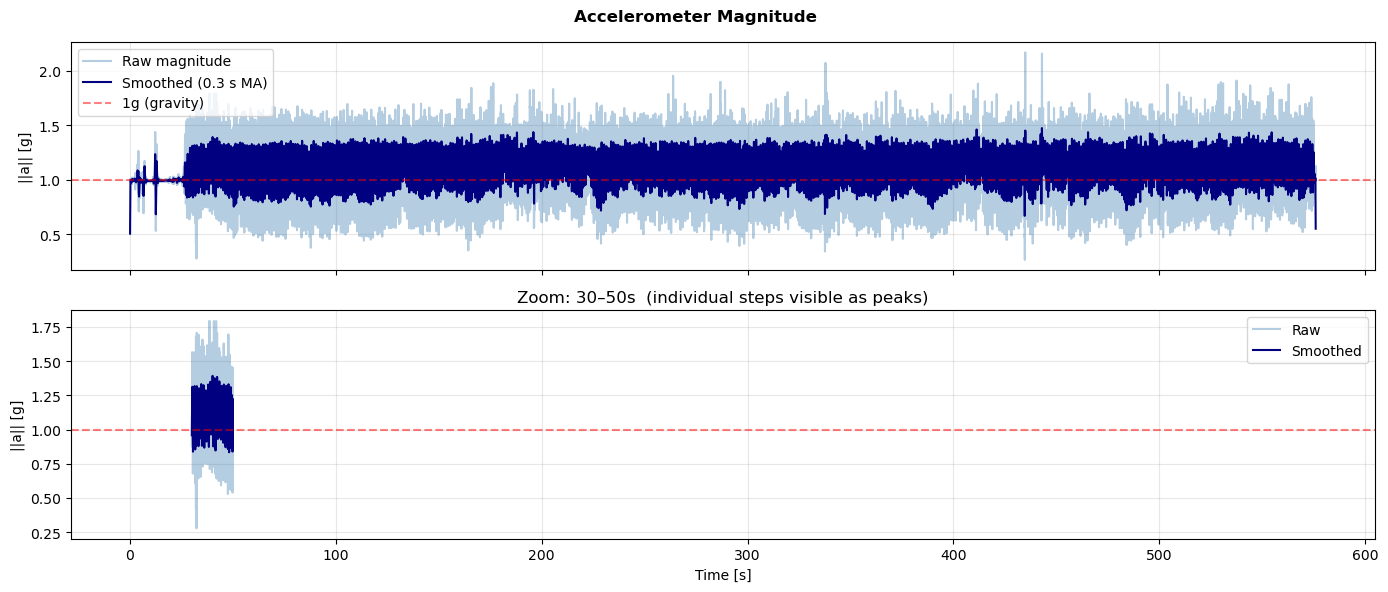

In [21]:
def compute_acc_mag(rec):
    ax = rec.data['ax'].values
    ay = rec.data['ay'].values
    az = rec.data['az'].values
    return np.sqrt(ax**2 + ay**2 + az**2)

def smooth(sig, window_s, sr):
    """Centred moving average."""
    w = max(1, int(window_s * sr))
    if w % 2 == 0:
        w += 1
    return np.convolve(sig, np.ones(w) / w, mode='same')

mag   = compute_acc_mag(rec)
t     = rec.data['ax'].timestamps
sr    = rec.data['ax'].samplerate
mag_s = smooth(mag, window_s=0.3, sr=sr)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(t, mag,   alpha=0.4, color='steelblue', label='Raw magnitude')
axes[0].plot(t, mag_s, color='navy',       label='Smoothed (0.3 s MA)')
axes[0].axhline(1.0, color='red', linestyle='--', alpha=0.5, label='1g (gravity)')
axes[0].set_ylabel('||a|| [g]')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Zoom into 20 s window to see individual steps
ZOOM_START, ZOOM_END = 30, 50
mask = (t >= ZOOM_START) & (t <= ZOOM_END)
axes[1].plot(t[mask], mag[mask],   alpha=0.4, color='steelblue', label='Raw')
axes[1].plot(t[mask], mag_s[mask], color='navy',       label='Smoothed')
axes[1].axhline(1.0, color='red', linestyle='--', alpha=0.5)
axes[1].set_ylabel('||a|| [g]')
axes[1].set_xlabel('Time [s]')
axes[1].set_title(f'Zoom: {ZOOM_START}–{ZOOM_END}s  (individual steps visible as peaks)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Accelerometer Magnitude', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Watch Location Comparison
Picking one walking recording per location and overlaying the acc magnitude.

Example files per location:
  Wrist   : train_trace_000.pkl
  Belt    : train_trace_001.pkl
  Ankle   : train_trace_002.pkl


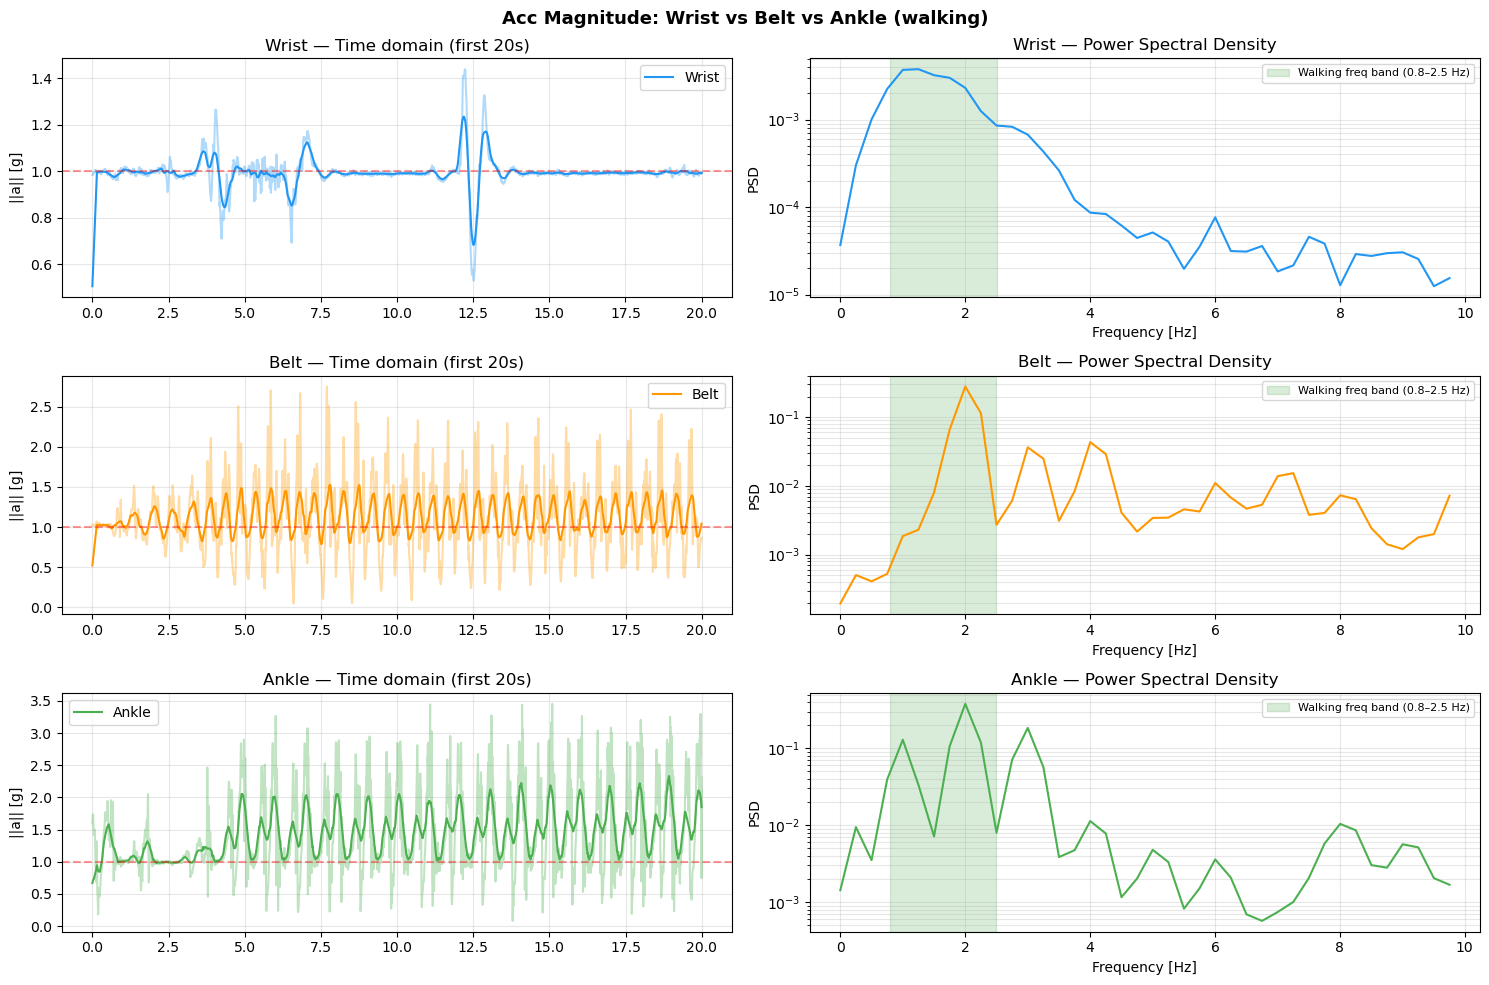

In [22]:
# Find one walking-only recording for each watch location
loc_examples = {}
for fpath, lbl in zip(train_files, all_labels):
    wl = lbl['watch_loc']
    a = normalize_acts(lbl.get('activities', {}))
    if wl not in loc_examples and a.get('walking') and not a.get('running') and not a.get('cycling'):
        loc_examples[wl] = fpath
    if len(loc_examples) == 3:
        break

print('Example files per location:')
for wl, fpath in sorted(loc_examples.items()):
    print(f'  {WATCH_LOC_NAMES[wl]:8s}: {os.path.basename(fpath)}')

fig, axes = plt.subplots(3, 2, figsize=(15, 10))
CLIP_S = 20

for row, (wl, fpath) in enumerate(sorted(loc_examples.items())):
    r     = Recording(fpath)
    mag   = compute_acc_mag(r)
    t     = r.data['ax'].timestamps
    sr    = r.data['ax'].samplerate
    mag_s = smooth(mag, 0.3, sr)
    color = WATCH_LOC_COLORS[wl]

    mask = t < CLIP_S
    axes[row, 0].plot(t[mask], mag[mask],   alpha=0.35, color=color)
    axes[row, 0].plot(t[mask], mag_s[mask], color=color, lw=1.5, label=WATCH_LOC_NAMES[wl])
    axes[row, 0].axhline(1.0, color='red', ls='--', alpha=0.4)
    axes[row, 0].set_ylabel('||a|| [g]')
    axes[row, 0].set_title(f'{WATCH_LOC_NAMES[wl]} — Time domain (first {CLIP_S}s)')
    axes[row, 0].legend()
    axes[row, 0].grid(alpha=0.3)

    seg = mag[mask]
    freqs, psd = scipy_signal.welch(seg, fs=sr, nperseg=min(len(seg), int(sr * 4)))
    freq_mask = freqs <= 10
    axes[row, 1].semilogy(freqs[freq_mask], psd[freq_mask], color=color)
    axes[row, 1].axvspan(0.8, 2.5, alpha=0.15, color='green', label='Walking freq band (0.8–2.5 Hz)')
    axes[row, 1].set_xlabel('Frequency [Hz]')
    axes[row, 1].set_ylabel('PSD')
    axes[row, 1].set_title(f'{WATCH_LOC_NAMES[wl]} — Power Spectral Density')
    axes[row, 1].legend(fontsize=8)
    axes[row, 1].grid(alpha=0.3, which='both')

plt.suptitle('Acc Magnitude: Wrist vs Belt vs Ankle (walking)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 7. Activity Comparison
Comparing acc magnitude signal characteristics across activities (one example per activity).

Example files per activity:
  walking   : train_trace_000.pkl  (loc=Wrist, path=0)
  cycling   : train_trace_006.pkl  (loc=Wrist, path=4)
  running   : train_trace_015.pkl  (loc=Ankle, path=1)


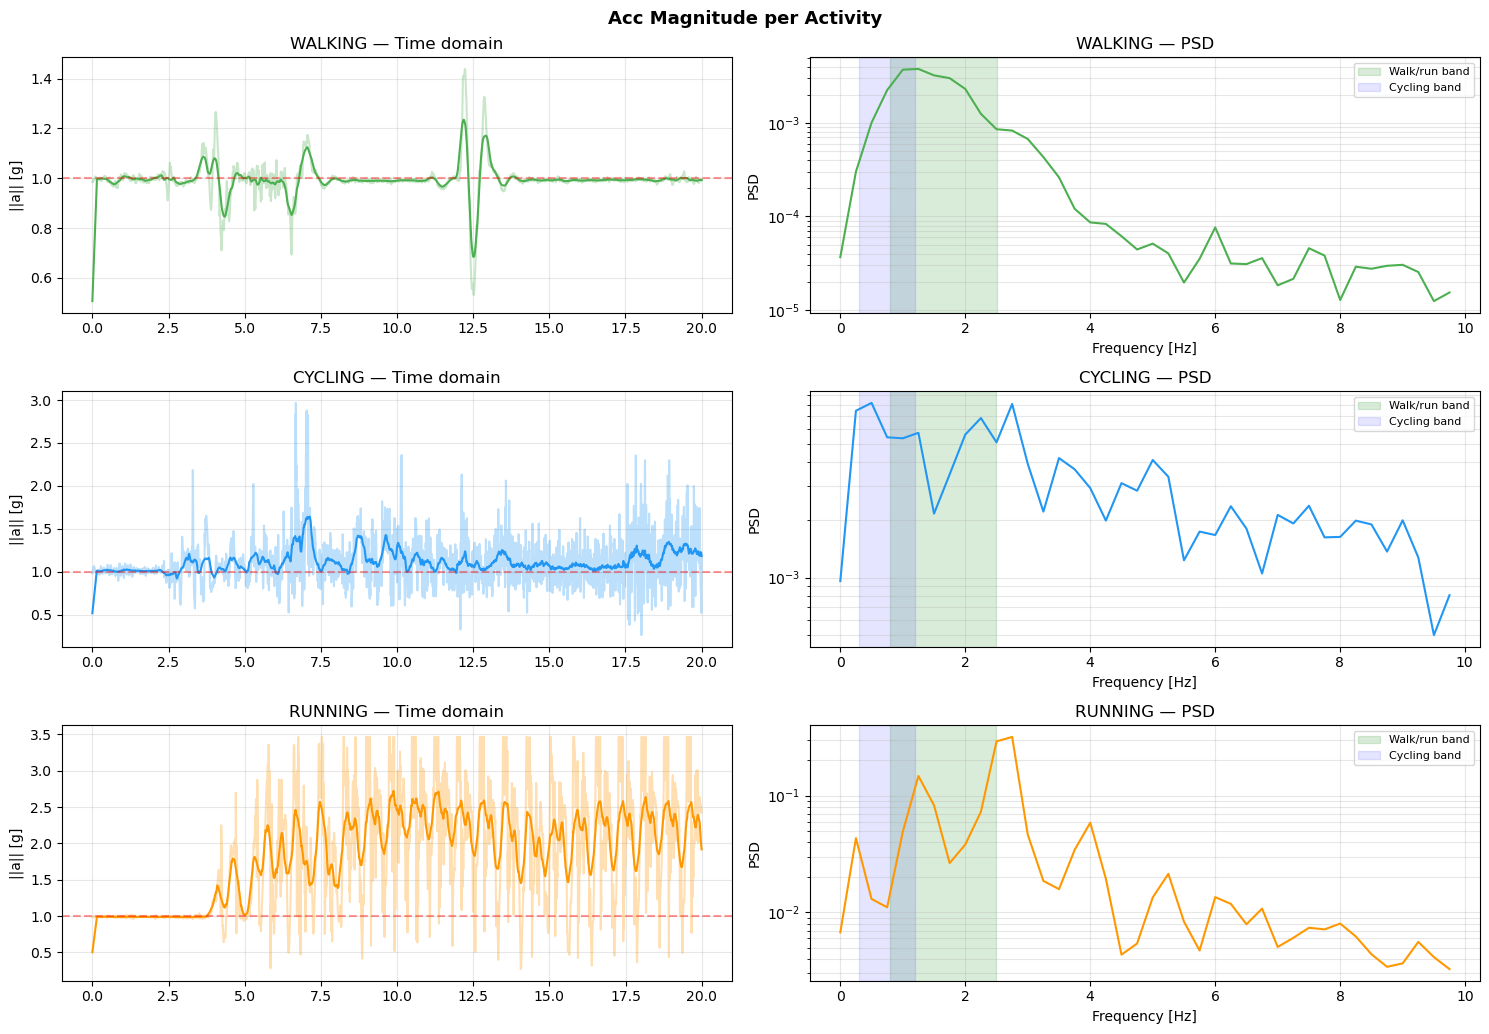

In [23]:
# Find one 'clean' example per activity (only that one activity true)
act_examples = {}
for fpath, lbl in zip(train_files, all_labels):
    a = normalize_acts(lbl.get('activities', {}))
    true_acts = [k for k, v in a.items() if v]
    if len(true_acts) == 1:
        act = true_acts[0]
        if act not in act_examples:
            act_examples[act] = fpath
    if len(act_examples) == 4:
        break

print('Example files per activity:')
for act, fpath in act_examples.items():
    lbl = all_labels[train_files.index(fpath)]
    print(f'  {act:10s}: {os.path.basename(fpath)}  (loc={WATCH_LOC_NAMES[lbl["watch_loc"]]}, path={lbl["path_idx"]})')

CLIP_S = 20
fig, axes = plt.subplots(len(act_examples), 2, figsize=(15, 3.5 * len(act_examples)))
if len(act_examples) == 1:
    axes = [axes]

for row, (act, fpath) in enumerate(act_examples.items()):
    r     = Recording(fpath)
    mag   = compute_acc_mag(r)
    t     = r.data['ax'].timestamps
    sr    = r.data['ax'].samplerate
    mag_s = smooth(mag, 0.3, sr)
    color = ACT_COLORS[act]

    mask = t < CLIP_S
    axes[row][0].plot(t[mask], mag[mask],   alpha=0.3, color=color)
    axes[row][0].plot(t[mask], mag_s[mask], color=color, lw=1.5)
    axes[row][0].axhline(1.0, color='red', ls='--', alpha=0.4)
    axes[row][0].set_ylabel('||a|| [g]')
    axes[row][0].set_title(f'{act.upper()} — Time domain')
    axes[row][0].grid(alpha=0.3)

    seg = mag[mask]
    if len(seg) > 64:
        freqs, psd = scipy_signal.welch(seg, fs=sr, nperseg=min(len(seg), int(sr * 4)))
        freq_mask = freqs <= 10
        axes[row][1].semilogy(freqs[freq_mask], psd[freq_mask], color=color)
        axes[row][1].axvspan(0.8, 2.5, alpha=0.15, color='green', label='Walk/run band')
        axes[row][1].axvspan(0.3, 1.2, alpha=0.10, color='blue',  label='Cycling band')
    axes[row][1].set_xlabel('Frequency [Hz]')
    axes[row][1].set_ylabel('PSD')
    axes[row][1].set_title(f'{act.upper()} — PSD')
    axes[row][1].legend(fontsize=8)
    axes[row][1].grid(alpha=0.3, which='both')

plt.suptitle('Acc Magnitude per Activity', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 8. Windowed Statistics per Activity

**How windows are labelled here:** Each window inherits the recording-level weak label. For a recording where only "walking" is true, every 5-second window is labelled "walking" — even though the first and last few seconds of the recording might actually be transitions. This is a crude but workable proxy for pure-activity windows.

**Why standing shows nothing:** There are **zero** pure single-activity standing recordings in the training set — standing always co-occurs with at least one other activity (participants typically walk to and from standstill points). The standing box plots will be empty because no windows pass the `len(true_acts)==1` filter. To study standing you'd need to use mixed recordings and segment by signal energy threshold.


In [ ]:
def extract_window_features(mag, sr, window_s=5.0, overlap=0.5):
    """Extract windowed features from acc magnitude signal."""
    w    = int(window_s * sr)
    step = int(w * (1 - overlap))
    means, stds, energies, dom_freqs = [], [], [], []
    for start in range(0, len(mag) - w, step):
        seg = mag[start:start + w]
        means.append(np.mean(seg))
        stds.append(np.std(seg))
        energies.append(np.sum(np.abs(np.fft.rfft(seg))**2) / len(seg))
        freqs = np.fft.rfftfreq(len(seg), d=1/sr)
        fft_mag = np.abs(np.fft.rfft(seg))
        band = (freqs >= 0.3) & (freqs <= 10)
        dom_freqs.append(freqs[band][np.argmax(fft_mag[band])] if band.any() else 0)
    return np.array(means), np.array(stds), np.array(energies), np.array(dom_freqs)

MAX_PER_ACT = 25
feat_data = {act: {'std': [], 'energy': [], 'dom_freq': [], 'mean': []} for act in ACT_COLORS}
counts = Counter()

for fpath, lbl in zip(train_files, all_labels):
    a = normalize_acts(lbl.get('activities', {}))
    true_acts = [k for k, v in a.items() if v]
    if len(true_acts) != 1:
        continue
    act = true_acts[0]
    if counts[act] >= MAX_PER_ACT:
        continue
    try:
        r   = Recording(fpath)
        mag = compute_acc_mag(r)
        sr  = r.data['ax'].samplerate
        mn, sd, en, df = extract_window_features(mag, sr)
        feat_data[act]['mean'].extend(mn)
        feat_data[act]['std'].extend(sd)
        feat_data[act]['energy'].extend(en)
        feat_data[act]['dom_freq'].extend(df)
        counts[act] += 1
    except Exception:
        pass

# Standing has no pure recordings — proxy: take low-energy windows from walking recordings
# (std < 0.05 g means the person is briefly stationary)
STANDING_STD_THRESH = 0.05
MAX_STANDING = 500
for fpath, lbl in zip(train_files, all_labels):
    if len(feat_data['standing']['std']) >= MAX_STANDING:
        break
    a = normalize_acts(lbl.get('activities', {}))
    if not a.get('standing'):
        continue
    try:
        r   = Recording(fpath)
        mag = compute_acc_mag(r)
        sr  = r.data['ax'].samplerate
        mn, sd, en, df = extract_window_features(mag, sr)
        # only keep windows that look like standing (very low std)
        mask = sd < STANDING_STD_THRESH
        feat_data['standing']['mean'].extend(mn[mask])
        feat_data['standing']['std'].extend(sd[mask])
        feat_data['standing']['energy'].extend(en[mask])
        feat_data['standing']['dom_freq'].extend(df[mask])
    except Exception:
        pass

print('Windows collected per activity:')
for act in ACT_COLORS:
    note = ' (proxy: low-std windows from mixed recordings)' if act == 'standing' else ''
    print(f'  {act:10s}: {len(feat_data[act]["std"])} windows{note}')


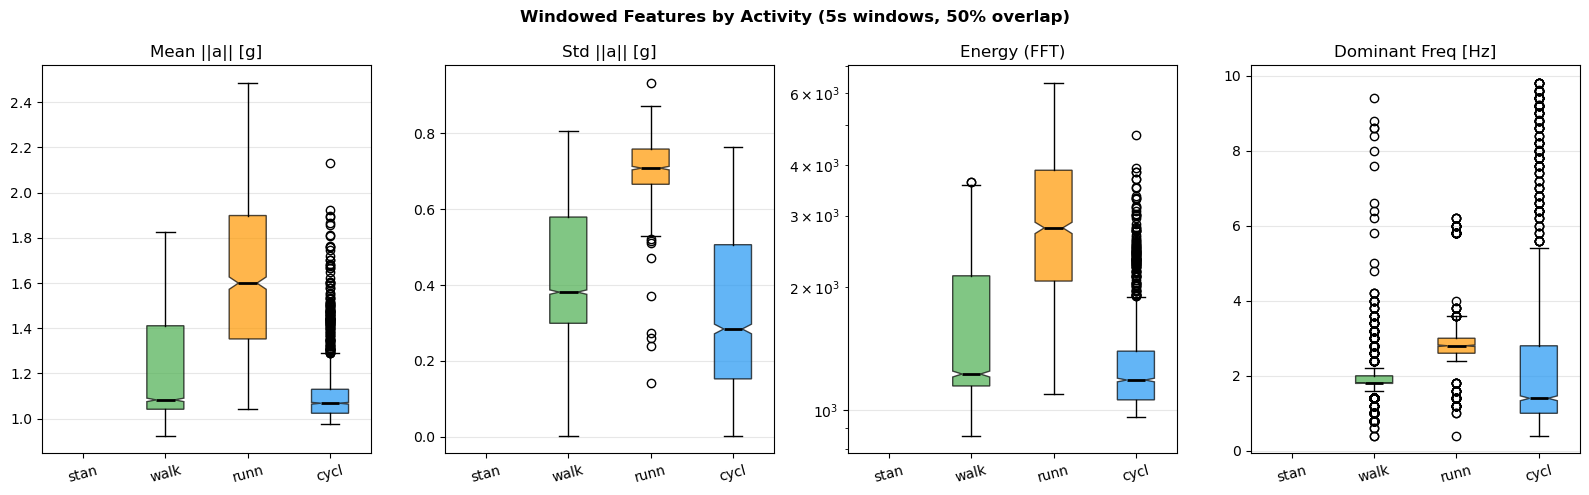

In [25]:
feat_names = ['mean', 'std', 'energy', 'dom_freq']
feat_labels = ['Mean ||a|| [g]', 'Std ||a|| [g]', 'Energy (FFT)', 'Dominant Freq [Hz]']
act_order   = ['standing', 'walking', 'running', 'cycling']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for col, (feat, label) in enumerate(zip(feat_names, feat_labels)):
    data   = [feat_data[act][feat] for act in act_order]
    colors = [ACT_COLORS[act] for act in act_order]
    bp = axes[col].boxplot(data, patch_artist=True, notch=True,
                           medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[col].set_xticks(range(1, len(act_order)+1))
    axes[col].set_xticklabels([a[:4] for a in act_order], rotation=15)
    axes[col].set_title(label)
    axes[col].grid(axis='y', alpha=0.3)
    if feat == 'energy':
        axes[col].set_yscale('log')

plt.suptitle('Windowed Features by Activity (5s windows, 50% overlap)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Path-Distinguishing Features
Duration, altitude range, and activity mix can all help separate the 5 paths.

In [26]:
path_durations  = {p: [] for p in range(5)}
path_alt_ranges = {p: [] for p in range(5)}
path_alt_gains  = {p: [] for p in range(5)}   # net elevation (end - start)
path_step_counts = {p: [] for p in range(5)}

for fpath, lbl in zip(train_files, all_labels):
    p = lbl['path_idx']
    sc = lbl.get('step_count', -1)
    try:
        with open(fpath, 'rb') as f:
            d = pickle.load(f)
        ax_trace = d['data']['ax']
        dur = (ax_trace['raw_timestamps'][-1][1] - ax_trace['raw_timestamps'][0][1]) / 1000
        path_durations[p].append(dur)
        if sc != -1:
            path_step_counts[p].append(sc)
        if 'altitude' in d['data']:
            alt_vals = np.array(d['data']['altitude']['values'])
            path_alt_ranges[p].append(alt_vals.max() - alt_vals.min())
            # net gain = mean of last 10% - mean of first 10%
            n10 = max(1, len(alt_vals) // 10)
            path_alt_gains[p].append(np.mean(alt_vals[-n10:]) - np.mean(alt_vals[:n10]))
    except Exception:
        pass

print('Path summary:')
print(f'{"Path":<6} {"n":<5} {"Dur mean [s]":<15} {"Dur std":<10} {"Alt range mean":<17} {"Net elev mean"}')
for p in range(5):
    d  = path_durations[p]
    ar = path_alt_ranges[p]
    ag = path_alt_gains[p]
    print(f'Path {p}  {len(d):<5} {np.mean(d):<15.1f} {np.std(d):<10.1f} '
          f'{np.mean(ar) if ar else float("nan"):<17.1f} {np.mean(ag) if ag else float("nan"):.1f}')

Path summary:
Path   n     Dur mean [s]    Dur std    Alt range mean    Net elev mean
Path 0  82    532.0           127.2      64.8              38.4
Path 1  76    562.0           121.5      72.0              39.4
Path 2  74    554.4           110.7      89.7              46.6
Path 3  71    510.1           116.9      66.1              -43.9
Path 4  93    518.2           113.3      51.1              -42.9


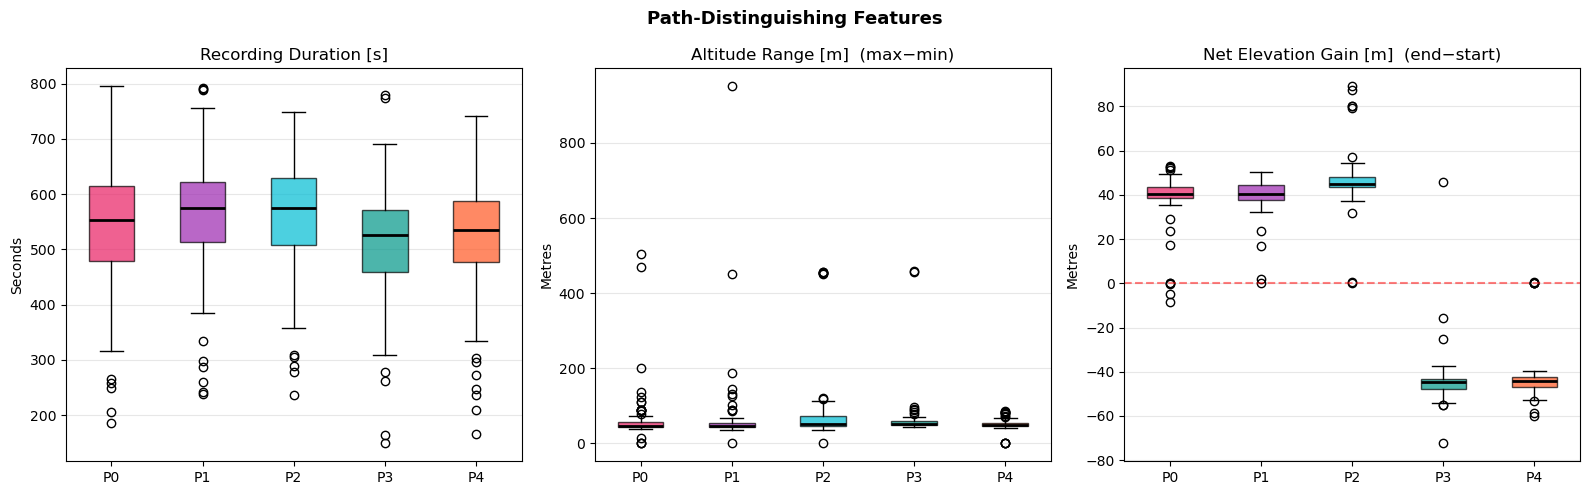

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Duration box plot
data_dur = [path_durations[p] for p in range(5)]
bp = axes[0].boxplot(data_dur, patch_artist=True,
                      medianprops=dict(color='black', lw=2))
for patch, p in zip(bp['boxes'], range(5)):
    patch.set_facecolor(PATH_COLORS[p]); patch.set_alpha(0.7)
axes[0].set_xticklabels([f'P{p}' for p in range(5)])
axes[0].set_title('Recording Duration [s]')
axes[0].set_ylabel('Seconds')
axes[0].grid(axis='y', alpha=0.3)

# Altitude range
data_ar = [path_alt_ranges[p] for p in range(5)]
bp2 = axes[1].boxplot([x for x in data_ar], patch_artist=True,
                       medianprops=dict(color='black', lw=2))
for patch, p in zip(bp2['boxes'], range(5)):
    patch.set_facecolor(PATH_COLORS[p]); patch.set_alpha(0.7)
axes[1].set_xticklabels([f'P{p}' for p in range(5)])
axes[1].set_title('Altitude Range [m]  (max−min)')
axes[1].set_ylabel('Metres')
axes[1].grid(axis='y', alpha=0.3)

# Net elevation gain
data_ag = [path_alt_gains[p] for p in range(5)]
bp3 = axes[2].boxplot([x for x in data_ag], patch_artist=True,
                       medianprops=dict(color='black', lw=2))
for patch, p in zip(bp3['boxes'], range(5)):
    patch.set_facecolor(PATH_COLORS[p]); patch.set_alpha(0.7)
axes[2].axhline(0, color='red', ls='--', alpha=0.5)
axes[2].set_xticklabels([f'P{p}' for p in range(5)])
axes[2].set_title('Net Elevation Gain [m]  (end−start)')
axes[2].set_ylabel('Metres')
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Path-Distinguishing Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

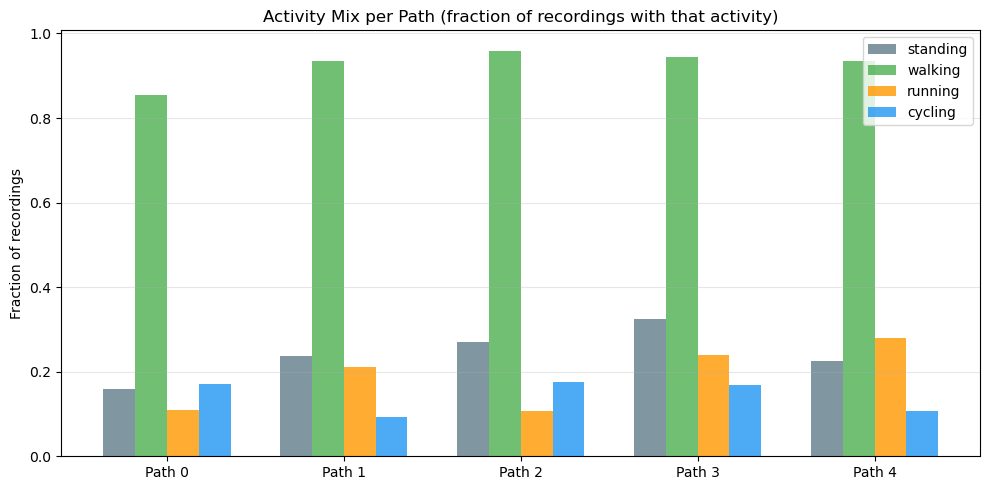

In [28]:
# Activity mix per path — useful for path classification
path_act_mix = {p: {'standing': 0, 'walking': 0, 'running': 0, 'cycling': 0, 'total': 0}
                for p in range(5)}

for lbl in all_labels:
    p = lbl['path_idx']
    a = normalize_acts(lbl.get('activities', {}))
    path_act_mix[p]['total'] += 1
    for act in ['standing', 'walking', 'running', 'cycling']:
        if a.get(act, False):
            path_act_mix[p][act] += 1

fig, ax = plt.subplots(figsize=(10, 5))
bar_w = 0.18
x = np.arange(5)
for i, act in enumerate(['standing', 'walking', 'running', 'cycling']):
    fracs = [path_act_mix[p][act] / path_act_mix[p]['total'] for p in range(5)]
    ax.bar(x + i * bar_w, fracs, bar_w, label=act, color=ACT_COLORS[act], alpha=0.8)

ax.set_xticks(x + bar_w * 1.5)
ax.set_xticklabels([f'Path {p}' for p in range(5)])
ax.set_ylabel('Fraction of recordings')
ax.set_title('Activity Mix per Path (fraction of recordings with that activity)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 10. Step Count — Ground Truth Overview
Steps are only labeled for TA-team recordings. Understand the distribution and how step count varies with duration and watch location.

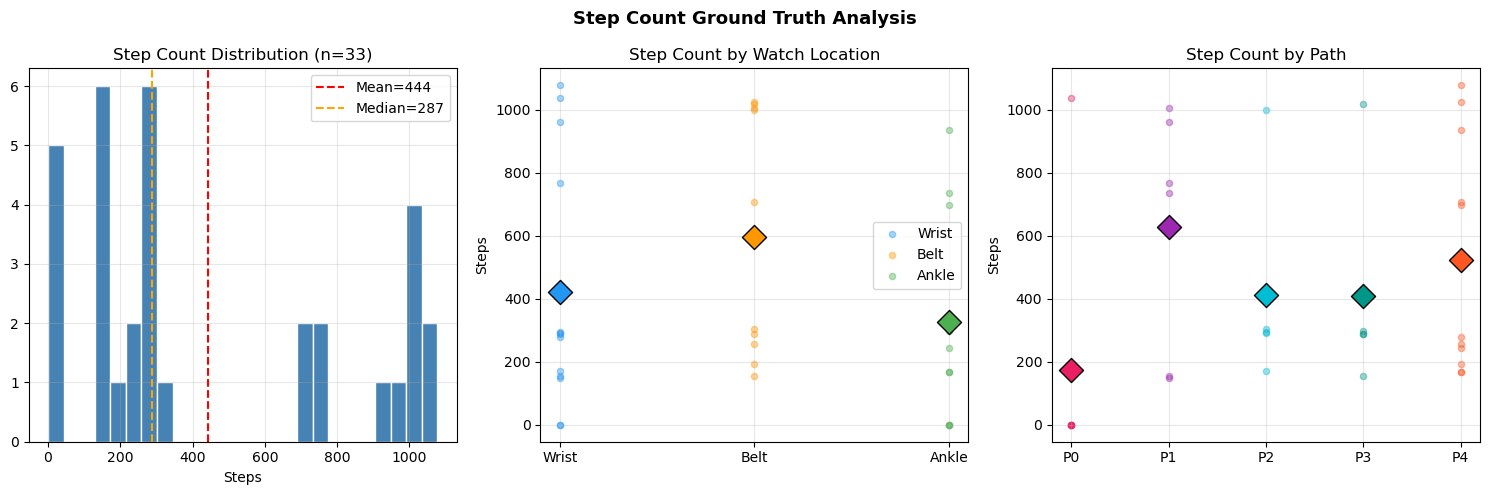

In [29]:

step_data = [(int(lbl['step_count']), lbl['watch_loc'], lbl['path_idx'])
             for lbl in all_labels if has_valid_step(lbl.get('step_count'))]
step_vals  = np.array([s for s, _, _ in step_data])
step_locs  = [wl for _, wl, _ in step_data]
step_paths = [p for _, _, p in step_data]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Distribution overall
axes[0].hist(step_vals, bins=25, color='steelblue', edgecolor='white')
axes[0].axvline(np.mean(step_vals), color='red', ls='--', label=f'Mean={np.mean(step_vals):.0f}')
axes[0].axvline(np.median(step_vals), color='orange', ls='--', label=f'Median={np.median(step_vals):.0f}')
axes[0].set_title(f'Step Count Distribution (n={len(step_vals)})')
axes[0].set_xlabel('Steps')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Per watch location
for wl in range(3):
    vals = [s for s, wl2, _ in step_data if wl2 == wl]
    axes[1].scatter([wl] * len(vals), vals, color=WATCH_LOC_COLORS[wl],
                    alpha=0.4, s=20, label=WATCH_LOC_NAMES[wl])
    axes[1].scatter([wl], [np.mean(vals)], color=WATCH_LOC_COLORS[wl],
                    s=150, marker='D', edgecolors='black', zorder=5)
axes[1].set_xticks(range(3))
axes[1].set_xticklabels([WATCH_LOC_NAMES[k] for k in range(3)])
axes[1].set_title('Step Count by Watch Location')
axes[1].set_ylabel('Steps')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Per path
for p in range(5):
    vals = [s for s, _, p2 in step_data if p2 == p]
    axes[2].scatter([p] * len(vals), vals, color=PATH_COLORS[p], alpha=0.4, s=20)
    if vals:
        axes[2].scatter([p], [np.mean(vals)], color=PATH_COLORS[p],
                        s=150, marker='D', edgecolors='black', zorder=5)
axes[2].set_xticks(range(5))
axes[2].set_xticklabels([f'P{p}' for p in range(5)])
axes[2].set_title('Step Count by Path')
axes[2].set_ylabel('Steps')
axes[2].grid(alpha=0.3)

plt.suptitle('Step Count Ground Truth Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 11. Watch Location — Feature Separability
How well do simple windowed features separate the three watch locations?

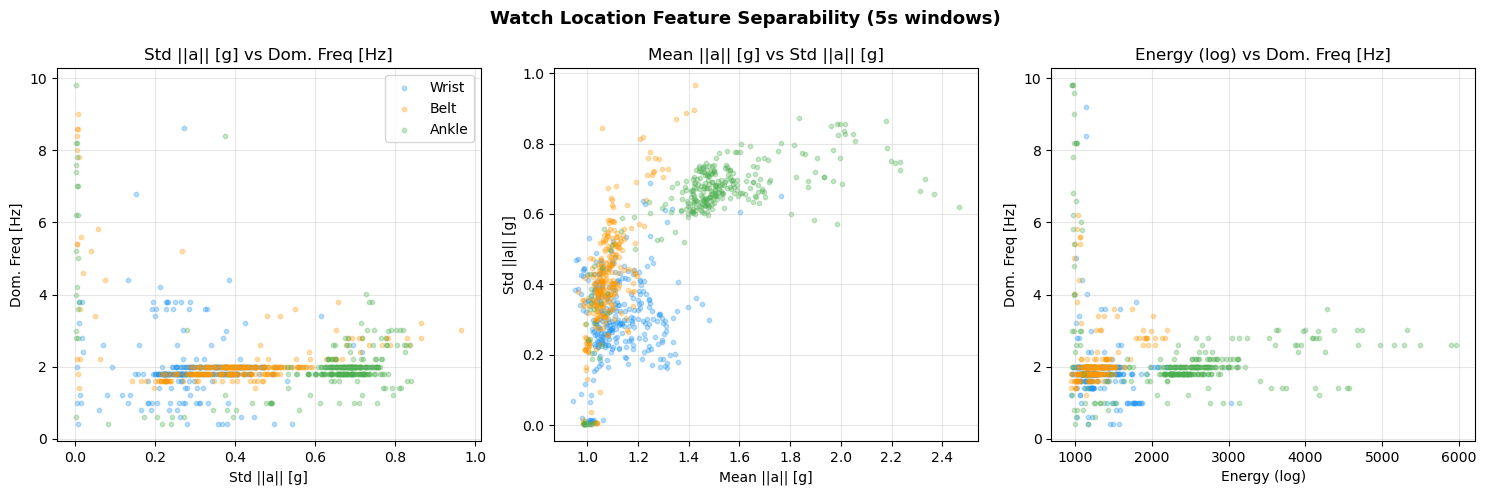

In [30]:
MAX_PER_LOC = 30
loc_feat = {wl: {'std': [], 'energy': [], 'dom_freq': [], 'mean': []} for wl in range(3)}
loc_counts = Counter()

for fpath, lbl in zip(train_files, all_labels):
    wl = lbl['watch_loc']
    if loc_counts[wl] >= MAX_PER_LOC:
        continue
    try:
        r   = Recording(fpath)
        mag = compute_acc_mag(r)
        sr  = r.data['ax'].samplerate
        mn, sd, en, df = extract_window_features(mag, sr)
        loc_feat[wl]['mean'].extend(mn)
        loc_feat[wl]['std'].extend(sd)
        loc_feat[wl]['energy'].extend(en)
        loc_feat[wl]['dom_freq'].extend(df)
        loc_counts[wl] += 1
    except Exception:
        pass

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
feat_pairs = [('std', 'dom_freq'), ('mean', 'std'), ('energy', 'dom_freq')]
feat_axis_labels = {'std': 'Std ||a|| [g]', 'dom_freq': 'Dom. Freq [Hz]',
                    'mean': 'Mean ||a|| [g]', 'energy': 'Energy (log)'}

for col, (fx, fy) in enumerate(feat_pairs):
    for wl in range(3):
        xdata = np.array(loc_feat[wl][fx])
        ydata = np.array(loc_feat[wl][fy])
        # subsample for readability
        idx = np.random.choice(len(xdata), size=min(300, len(xdata)), replace=False)
        axes[col].scatter(xdata[idx],
                          np.log10(ydata[idx]) if fy == 'energy' else ydata[idx],
                          color=WATCH_LOC_COLORS[wl], alpha=0.3, s=10,
                          label=WATCH_LOC_NAMES[wl])
    axes[col].set_xlabel(feat_axis_labels[fx])
    axes[col].set_ylabel(('log10 ' if fy == 'energy' else '') + feat_axis_labels[fy])
    axes[col].set_title(f'{feat_axis_labels[fx]} vs {feat_axis_labels[fy]}')
    if col == 0:
        axes[col].legend()
    axes[col].grid(alpha=0.3)

plt.suptitle('Watch Location Feature Separability (5s windows)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Summary & Key Observations

Fill in your findings here as you explore:

### Sensor availability (both train AND test)
- **Always present (35 sensors):** smartwatch axes (ax/ay/az @ 200 Hz, gx/gy/gz @ 200 Hz, mx/my/mz @ 12.5 Hz), temperature, timestamp, phone IMU (accel/gyro/gravity/linear-acc/rotation @ ~200 Hz), phone magnetometer, phone orientation
- **Often present:** `phone_pressure` (83% of test), GPS lat/lon/bearing/speed (~54% test — **FORBIDDEN as input**)
- **Sometimes present:** `phone_steps` (33% — **FORBIDDEN as input**), `phone_light` (31%), `phone_magrot*` (16%)
- **Conclusion:** Build on the 35 always-present sensors. `phone_pressure` (barometric) is a safe bonus feature for elevation.

### Step counting
- Step count labels: `None` or `-1` = unlabeled, `numpy.int64` = actual count
- Ground truth available for **33 recordings** (TA team only, hand-counted)
- Ankle placement gives cleanest peaks (high amplitude, clear periodicity)
- Wrist placement adds arm-swing noise; belt is intermediate
- Typical step frequency: **1–2 Hz** (1 step every 0.5–1 s)

### Activity recognition
- Standing → very low std, energy ≈ gravity only
- Walking → moderate std, dominant freq 1–2 Hz
- Running → higher amplitude + higher dominant freq (2–3 Hz)
- Cycling → distinct low-frequency periodicity, lower acc variance than running
- Labels are **weak** — no timing info, just presence/absence

### Path classification
- Paths 0 & 1 are very similar (both uphill, ~830/840 m) — hardest to separate
- Paths 2 & 3 are reverse directions (altitude profile mirrored)
- Path 4 is shortest (780 m) and distinct in direction/terrain
- Net elevation from GPS altitude can indicate uphill (0,1,2) vs downhill (3,4)
- Recording duration varies but overlaps between paths

### Things to investigate further
- [ ] Does gyroscope help distinguish watch locations?
- [ ] Does magnetometer heading change pattern differ per path?
- [ ] How reliable is phone barometric pressure for elevation?
- [ ] What is the effect of running speed on acc magnitude amplitude?
- [ ] Do paths 0 and 1 differ in turn patterns (gyro heading)?


## 13. Does Gyroscope Help Distinguish Watch Locations?
Gyroscope captures rotational motion. Wrist rotation during walking (arm swing) is very different from ankle rotation (foot rotation at heel strike) and belt (minimal rotation).

In [ ]:
def compute_gyro_mag(rec):
    return np.sqrt(rec.data['gx'].values**2 + rec.data['gy'].values**2 + rec.data['gz'].values**2)

MAX_PER_LOC = 20
gyro_feat = {wl: {'std': [], 'mean': [], 'energy': []} for wl in range(3)}
acc_feat   = {wl: {'std': [], 'mean': [], 'energy': []} for wl in range(3)}
gyro_counts = Counter()

for fpath, lbl in zip(train_files, all_labels):
    wl = lbl['watch_loc']
    a  = normalize_acts(lbl.get('activities', {}))
    if gyro_counts[wl] >= MAX_PER_LOC:
        continue
    if not a.get('walking'):
        continue
    try:
        r     = Recording(fpath)
        gmag  = compute_gyro_mag(r)
        amag  = compute_acc_mag(r)
        sr    = r.data['gx'].samplerate
        w = int(5.0 * sr); step = w // 2
        for start in range(0, len(gmag) - w, step):
            gseg = gmag[start:start+w]
            aseg = amag[start:start+w]
            gyro_feat[wl]['std'].append(np.std(gseg))
            gyro_feat[wl]['mean'].append(np.mean(gseg))
            gyro_feat[wl]['energy'].append(np.sum(np.fft.rfft(gseg)**2) / w)
            acc_feat[wl]['std'].append(np.std(aseg))
        gyro_counts[wl] += 1
    except Exception:
        pass

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Gyro std box plot per location
bp = axes[0].boxplot([gyro_feat[wl]['std'] for wl in range(3)], patch_artist=True,
                      medianprops=dict(color='black', lw=2))
for patch, wl in zip(bp['boxes'], range(3)):
    patch.set_facecolor(WATCH_LOC_COLORS[wl]); patch.set_alpha(0.7)
axes[0].set_xticklabels([WATCH_LOC_NAMES[wl] for wl in range(3)])
axes[0].set_title('Gyro magnitude Std [deg/s]')
axes[0].set_ylabel('Std of ||ω||')
axes[0].grid(axis='y', alpha=0.3)

# Gyro mean
bp2 = axes[1].boxplot([gyro_feat[wl]['mean'] for wl in range(3)], patch_artist=True,
                       medianprops=dict(color='black', lw=2))
for patch, wl in zip(bp2['boxes'], range(3)):
    patch.set_facecolor(WATCH_LOC_COLORS[wl]); patch.set_alpha(0.7)
axes[1].set_xticklabels([WATCH_LOC_NAMES[wl] for wl in range(3)])
axes[1].set_title('Gyro magnitude Mean [deg/s]')
axes[1].grid(axis='y', alpha=0.3)

# 2D scatter: acc std vs gyro std — best 2D separator
for wl in range(3):
    n = min(300, len(acc_feat[wl]['std']))
    idx = np.random.choice(len(acc_feat[wl]['std']), n, replace=False)
    axes[2].scatter(np.array(acc_feat[wl]['std'])[idx],
                    np.array(gyro_feat[wl]['std'])[idx],
                    color=WATCH_LOC_COLORS[wl], alpha=0.3, s=10,
                    label=WATCH_LOC_NAMES[wl])
axes[2].set_xlabel('Acc magnitude Std [g]')
axes[2].set_ylabel('Gyro magnitude Std [deg/s]')
axes[2].set_title('Acc Std vs Gyro Std — Watch Location')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle('Gyroscope as Watch Location Feature (walking recordings)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 14. Barometric Pressure vs Altitude — How Reliable?
`phone_pressure` (hPa) is present in ~83% of recordings. Barometric pressure decreases with elevation, so it should track the altitude signal. This matters for path classification since paths differ in elevation gain direction.

In [ ]:
# Find a few recordings with both altitude and pressure, covering different paths
pressure_examples = {}
for fpath, lbl in zip(train_files, all_labels):
    p = lbl['path_idx']
    if p in pressure_examples:
        continue
    with open(fpath, 'rb') as f:
        d = pickle.load(f)
    if 'altitude' in d['data'] and 'phone_pressure' in d['data']:
        pressure_examples[p] = fpath
    if len(pressure_examples) == 5:
        break

print(f'Found pressure+altitude examples for paths: {sorted(pressure_examples.keys())}')

fig, axes = plt.subplots(len(pressure_examples), 2, figsize=(14, 3.5 * len(pressure_examples)), sharex='row')

for row, (p, fpath) in enumerate(sorted(pressure_examples.items())):
    r   = Recording(fpath)
    alt = r.data['altitude']
    prs = r.data['phone_pressure']

    ax_a = axes[row][0]
    ax_p = axes[row][1]

    ax_a.plot(alt.timestamps, alt.values, color=PATH_COLORS[p])
    ax_a.set_ylabel('GPS Altitude [m]')
    ax_a.set_title(f'Path {p} — GPS Altitude')
    ax_a.grid(alpha=0.3)

    # Invert pressure axis: higher pressure = lower elevation
    ax_p.plot(prs.timestamps, prs.values, color=PATH_COLORS[p])
    ax_p.invert_yaxis()
    ax_p.set_ylabel('Pressure [hPa] (inverted)')
    ax_p.set_title(f'Path {p} — Barometric Pressure (inverted = higher = up)')
    ax_p.grid(alpha=0.3)

    if row == len(pressure_examples) - 1:
        ax_a.set_xlabel('Time [s]')
        ax_p.set_xlabel('Time [s]')

plt.suptitle('GPS Altitude vs Barometric Pressure per Path', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Quantify: net pressure change correlates with direction of travel (uphill vs downhill)
print('\nNet pressure change by path (negative = pressure drops = going up):')
for p in range(5):
    deltas = []
    for fpath, lbl in zip(train_files, all_labels):
        if lbl['path_idx'] != p:
            continue
        with open(fpath, 'rb') as f:
            d = pickle.load(f)
        if 'phone_pressure' not in d['data']:
            continue
        vals = np.array(d['data']['phone_pressure']['values'])
        n10 = max(1, len(vals)//10)
        deltas.append(np.mean(vals[-n10:]) - np.mean(vals[:n10]))
    if deltas:
        print(f'  Path {p}: mean Δp = {np.mean(deltas):+.2f} hPa  (n={len(deltas)})')


## 15. Paths 0 vs 1 — Can We Separate Them?
Paths 0 and 1 are nearly identical routes (both Central→Main, same elevation gain). They differ only in one street: path 1 adds Clausiusstrasse as a detour (+10m distance). We check **phone** magnetometer heading (more stable than wrist-worn watch magnetometer) and recording duration as potential discriminators.

In [ ]:
def heading_from_mag(rec):
    """Compute compass heading (degrees) from phone magnetometer x/y (more stable than wrist watch)."""
    mx = rec.data['phone_mx'].values
    my = rec.data['phone_my'].values
    heading = np.degrees(np.arctan2(my, mx)) % 360
    return rec.data['phone_mx'].timestamps, heading

def resample_to_n(arr, n=200):
    """Resample array to n points for alignment."""
    idx = np.linspace(0, len(arr)-1, n).astype(int)
    return arr[idx]

# Collect heading trajectories for paths 0 and 1
path01_headings = {0: [], 1: []}
path01_durations = {0: [], 1: []}
MAX_EACH = 15

for fpath, lbl in zip(train_files, all_labels):
    p = lbl['path_idx']
    if p not in (0, 1):
        continue
    if len(path01_headings[p]) >= MAX_EACH:
        continue
    try:
        r = Recording(fpath)
        t_h, h = heading_from_mag(r)
        path01_headings[p].append(resample_to_n(h, 200))
        path01_durations[p].append(r.data['ax'].total_time)
    except Exception:
        pass

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Mean heading trajectory per path
x_norm = np.linspace(0, 100, 200)
for p, color, label in [(0, PATH_COLORS[0], 'Path 0'), (1, PATH_COLORS[1], 'Path 1')]:
    if not path01_headings[p]:
        continue
    stack = np.stack(path01_headings[p])
    stack_uw = np.unwrap(stack * np.pi / 180, axis=1) * 180 / np.pi
    mean_h = np.mean(stack_uw, axis=0)
    std_h  = np.std(stack_uw, axis=0)
    axes[0].plot(x_norm, mean_h, color=color, lw=2, label=label)
    axes[0].fill_between(x_norm, mean_h - std_h, mean_h + std_h, color=color, alpha=0.15)

axes[0].set_xlabel('Recording progress [%]')
axes[0].set_ylabel('Heading (unwrapped) [°]')
axes[0].set_title('Mean Heading Trajectory\n(phone magnetometer)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Distribution of heading values (binned into 36 × 10° bins)
for p, color, label in [(0, PATH_COLORS[0], 'Path 0'), (1, PATH_COLORS[1], 'Path 1')]:
    all_h = np.concatenate(path01_headings[p]) if path01_headings[p] else np.array([])
    if len(all_h) == 0:
        continue
    axes[1].hist(all_h % 360, bins=36, range=(0, 360), density=True,
                 color=color, alpha=0.5, label=label)
axes[1].set_xlabel('Heading [°]  (0/360=North, 90=East)')
axes[1].set_ylabel('Density')
axes[1].set_title('Heading Distribution\nPaths 0 vs 1 (phone mag)')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Duration distributions
axes[2].hist(path01_durations[0], bins=15, color=PATH_COLORS[0], alpha=0.6, label='Path 0', density=True)
axes[2].hist(path01_durations[1], bins=15, color=PATH_COLORS[1], alpha=0.6, label='Path 1', density=True)
axes[2].axvline(np.mean(path01_durations[0]), color=PATH_COLORS[0], ls='--', lw=2,
                label=f'Mean P0={np.mean(path01_durations[0]):.0f}s')
axes[2].axvline(np.mean(path01_durations[1]), color=PATH_COLORS[1], ls='--', lw=2,
                label=f'Mean P1={np.mean(path01_durations[1]):.0f}s')
axes[2].set_xlabel('Duration [s]')
axes[2].set_ylabel('Density')
axes[2].set_title('Recording Duration\nPaths 0 vs 1')
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

plt.suptitle('Path 0 vs Path 1 Separation (phone magnetometer)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 16. Magnetometer Heading: All 5 Paths (Phone)
Using `phone_mx/my` instead of watch magnetometer — the phone stays in a pocket so its orientation tracks body/walking direction much more reliably than the wrist-worn watch.

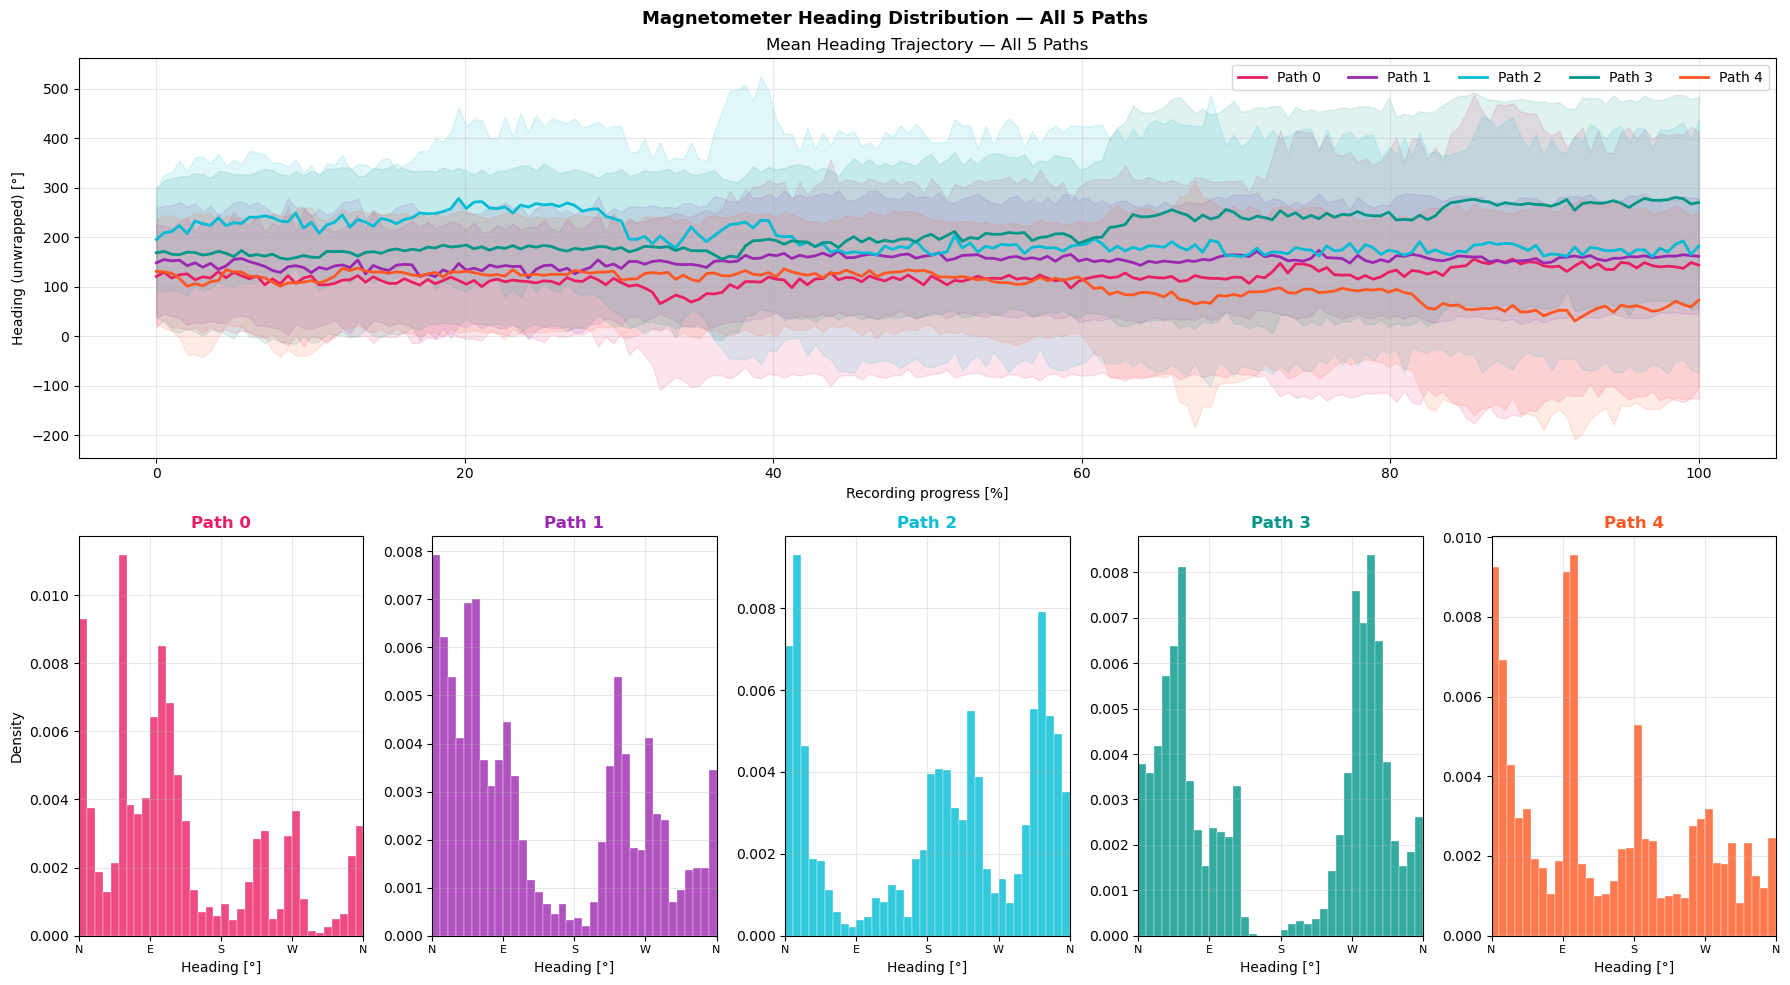

In [36]:
MAX_PER_PATH = 12
all_path_headings = {p: [] for p in range(5)}
path_heading_counts = Counter()

for fpath, lbl in zip(train_files, all_labels):
    p = lbl['path_idx']
    if path_heading_counts[p] >= MAX_PER_PATH:
        continue
    try:
        r = Recording(fpath)
        _, h = heading_from_mag(r)
        all_path_headings[p].append(resample_to_n(h, 200))
        path_heading_counts[p] += 1
    except Exception:
        pass

fig = plt.figure(figsize=(18, 10))

# Row 1: mean heading trajectory (progress %) per path
ax_traj = fig.add_subplot(2, 1, 1)
x_norm = np.linspace(0, 100, 200)
for p in range(5):
    if not all_path_headings[p]:
        continue
    stack = np.stack(all_path_headings[p])
    stack_uw = np.unwrap(stack * np.pi / 180, axis=1) * 180 / np.pi
    mean_h = np.mean(stack_uw, axis=0)
    std_h  = np.std(stack_uw, axis=0)
    ax_traj.plot(x_norm, mean_h, color=PATH_COLORS[p], lw=2, label=f'Path {p}')
    ax_traj.fill_between(x_norm, mean_h - std_h, mean_h + std_h,
                         color=PATH_COLORS[p], alpha=0.12)
ax_traj.set_xlabel('Recording progress [%]')
ax_traj.set_ylabel('Heading (unwrapped) [°]')
ax_traj.set_title('Mean Heading Trajectory — All 5 Paths')
ax_traj.legend(ncol=5)
ax_traj.grid(alpha=0.3)

# Row 2: heading histogram per path (polar-style via bar chart)
for col, p in enumerate(range(5)):
    ax_h = fig.add_subplot(2, 5, 6 + col)
    all_h = np.concatenate(all_path_headings[p]) if all_path_headings[p] else np.array([])
    if len(all_h) > 0:
        ax_h.hist(all_h % 360, bins=36, range=(0, 360), density=True,
                  color=PATH_COLORS[p], alpha=0.8, edgecolor='white', lw=0.3)
    ax_h.set_title(f'Path {p}', color=PATH_COLORS[p], fontweight='bold')
    ax_h.set_xlabel('Heading [°]')
    ax_h.set_xlim(0, 360)
    ax_h.set_xticks([0, 90, 180, 270, 360])
    ax_h.set_xticklabels(['N', 'E', 'S', 'W', 'N'], fontsize=8)
    ax_h.grid(alpha=0.3)
    if col == 0:
        ax_h.set_ylabel('Density')

plt.suptitle('Magnetometer Heading Distribution — All 5 Paths', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 17. Running Speed Effect on Acc Magnitude Amplitude
Faster running → higher stride frequency AND higher impact amplitude. We look at the relationship between dominant frequency (proxy for cadence/speed) and acc std (proxy for impact amplitude) for walking and running recordings.

In [ ]:
MAX_PER_ACT_SPEED = 30
speed_feat = {'walking': {'std': [], 'dom_freq': [], 'mean': []},
              'running': {'std': [], 'dom_freq': [], 'mean': []}}
speed_counts = Counter()

for fpath, lbl in zip(train_files, all_labels):
    a = normalize_acts(lbl.get('activities', {}))
    true_acts = [k for k, v in a.items() if v]
    if len(true_acts) != 1:
        continue
    act = true_acts[0]
    if act not in ('walking', 'running'):
        continue
    if speed_counts[act] >= MAX_PER_ACT_SPEED:
        continue
    try:
        r   = Recording(fpath)
        mag = compute_acc_mag(r)
        sr  = r.data['ax'].samplerate
        mn, sd, en, df = extract_window_features(mag, sr)
        speed_feat[act]['std'].extend(sd)
        speed_feat[act]['dom_freq'].extend(df)
        speed_feat[act]['mean'].extend(mn)
        speed_counts[act] += 1
    except Exception:
        pass

print(f'Windows: walking={len(speed_feat["walking"]["std"])}, running={len(speed_feat["running"]["std"])}')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

walk_color = ACT_COLORS['walking']
run_color  = ACT_COLORS['running']

# 1. Scatter: dom_freq vs acc_std — shows speed-amplitude relationship
for act, color in [('walking', walk_color), ('running', run_color)]:
    x = np.array(speed_feat[act]['dom_freq'])
    y = np.array(speed_feat[act]['std'])
    idx = np.random.choice(len(x), min(500, len(x)), replace=False)
    axes[0].scatter(x[idx], y[idx], color=color, alpha=0.3, s=12, label=act)
axes[0].set_xlabel('Dominant Frequency [Hz]  (stride cadence proxy)')
axes[0].set_ylabel('Acc magnitude Std [g]  (impact amplitude proxy)')
axes[0].set_title('Stride Freq vs Impact Amplitude\n(walking vs running)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2. Box plot: acc std per activity — amplitude comparison
bp = axes[1].boxplot([speed_feat['walking']['std'], speed_feat['running']['std']],
                     patch_artist=True, medianprops=dict(color='black', lw=2), notch=True)
for patch, color in zip(bp['boxes'], [walk_color, run_color]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[1].set_xticklabels(['Walking', 'Running'])
axes[1].set_title('Acc Std Distribution\n(impact amplitude)')
axes[1].set_ylabel('Std ||a|| [g]')
axes[1].grid(axis='y', alpha=0.3)

# 3. Box plot: dominant frequency — cadence comparison
bp2 = axes[2].boxplot([speed_feat['walking']['dom_freq'], speed_feat['running']['dom_freq']],
                      patch_artist=True, medianprops=dict(color='black', lw=2), notch=True)
for patch, color in zip(bp2['boxes'], [walk_color, run_color]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[2].set_xticklabels(['Walking', 'Running'])
axes[2].set_title('Dominant Freq Distribution\n(stride cadence)')
axes[2].set_ylabel('Dominant Freq [Hz]')
axes[2].axhspan(0.8, 2.0, alpha=0.08, color='green', label='Walk band 0.8–2 Hz')
axes[2].axhspan(2.0, 3.5, alpha=0.08, color='orange', label='Run band 2–3.5 Hz')
axes[2].legend(fontsize=8)
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Effect of Running Speed on Acc Magnitude Amplitude', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary statistics
for act in ('walking', 'running'):
    std_arr = np.array(speed_feat[act]['std'])
    df_arr  = np.array(speed_feat[act]['dom_freq'])
    print(f'{act:10s}  acc_std: {np.median(std_arr):.3f}g (median)   dom_freq: {np.median(df_arr):.2f} Hz (median)')
